# Customer Segmentation & Retention Analysis

This notebook builds a full **customer analytics pipeline** on the Online Retail dataset.  
It combines **unsupervised learning** for customer segmentation and **supervised learning** for churn / retention-risk prediction.

## Main objectives
- Clean raw transaction data and keep only valid purchase behavior
- Engineer customer-level behavioral features
- Compare **KMeans (baseline)** vs **Autoencoder + KMeans**
- Use **cohort retention analysis** for descriptive repeat-purchase behavior
- Build a **time-aware churn model** with a leakage check and corrected target design
- Interpret the final models with readable plots and export business-ready outputs

## Review-driven updates applied
- Added an explicit **KMeans vs AE+KMeans** comparison table
- Replaced training-size learning curves with **optimization / convergence curves**
- Clarified the purpose of the **cohort retention heatmap** and how it differs from the **Spearman correlation heatmap**
- Changed autoencoder loss plots to use a **log y-axis**
- Removed `class_weight` from randomized hyperparameter tuning and tested it only as an **on/off analysis**
- Broadened the learning-rate search range for boosting
- Fixed the biggest supervised-learning issue: **target leakage caused by using `recency_days` to define churn while also feeding it into the model**


## Module 0: Setup and Imports

This module imports all required libraries, configures display options, and defines reusable helper utilities used later in the notebook.

### What happens here
- Suppresses warning noise for cleaner output
- Imports data handling libraries such as `pandas` and `numpy`
- Imports plotting tools from `matplotlib`
- Imports preprocessing, clustering, model selection, and evaluation tools from `scikit-learn`
- Defines a custom blue-white-red heatmap and a reusable plotting helper for annotated heatmaps

This module acts as the **foundation** for the rest of the analysis.


In [3]:
# Purpose:
# Import required libraries, configure notebook display behavior, and define
# a reusable annotated heatmap function that will be used throughout the analysis.

# If you get missing packages, install them (uncomment):
# !pip install pandas numpy matplotlib scikit-learn openpyxl
# Deep learning autoencoder:
# !pip install torch

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, Normalize
from IPython.display import display

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, log_loss,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

pd.set_option("display.max_columns", 200)

BWR_CMAP = LinearSegmentedColormap.from_list(
    "blue_white_red",
    ["#2166ac", "#ffffff", "#b2182b"]
)

def plot_annotated_heatmap(
    data,
    xlabels,
    ylabels,
    title,
    cbar_label="",
    fmt=".3f",
    figsize=(10, 8),
    vmin=None,
    vmax=None,
    center=None,
    xlabel="",
    ylabel=""
):
    """Plot a heatmap with numeric annotations inside each cell.

    This helper is used for both correlation analysis and cohort-retention
    analysis so that the notebook presents values directly on the heatmap.
    """
    values = np.asarray(data, dtype=float)

    if vmin is None:
        vmin = np.nanmin(values)
    if vmax is None:
        vmax = np.nanmax(values)

    if center is not None:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    plt.figure(figsize=figsize)
    im = plt.imshow(values, aspect="auto", cmap=BWR_CMAP, norm=norm)

    plt.xticks(range(len(xlabels)), xlabels, rotation=60, ha="right")
    plt.yticks(range(len(ylabels)), ylabels)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    cbar = plt.colorbar(im)
    if cbar_label:
        cbar.set_label(cbar_label)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            if np.isnan(val):
                text = "NA"
                text_color = "black"
            else:
                text = format(val, fmt)
                rgba = BWR_CMAP(norm(val))
                luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                text_color = "black" if luminance > 0.6 else "white"

            plt.text(j, i, text, ha="center", va="center", color=text_color, fontsize=9)

    plt.tight_layout()
    plt.show()

from sklearn.base import clone
from scipy.stats import randint, loguniform


## Module 1: Load Dataset

This module locates and loads the input Excel file into a raw dataframe.

### What happens here
- Checks several common file locations for `Online Retail.xlsx`
- Loads the dataset with `pandas.read_excel`
- Displays the first few rows so the structure of the raw transactional data can be inspected

The output of this section is `df_raw`, which is the untouched source dataset used for all later processing.


In [4]:
# Purpose:
# Search a few likely locations for the Excel file, load it into memory, and
# preview the first rows of the raw transactional dataset.

candidate_paths = [
    Path("/content/Online Retail.xlsx"),
    Path("Online Retail.xlsx"),
    Path("./Online Retail.xlsx"),
    Path("/mnt/data/Online Retail.xlsx"),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), candidate_paths[0])
print("Using dataset path:", DATA_PATH)

df_raw = pd.read_excel(DATA_PATH)
df_raw.head()


Using dataset path: /content/Online Retail.xlsx


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# Purpose:
# Perform a quick structural inspection of the raw dataset before cleaning.
# This helps verify the shape, data types, and missing-value pattern.

print("Shape:", df_raw.shape)
display(df_raw.dtypes)
display(df_raw.isna().mean().sort_values(ascending=False).head(12))


Shape: (541909, 8)


,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


,0
CustomerID,0.249267
Description,0.002683
StockCode,0.000000
InvoiceNo,0.000000
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
Country,0.000000


## Module 2: Data Cleaning

This module prepares the transactional dataset so the analysis reflects **actual completed purchases** instead of noisy or invalid records.

### Cleaning rules applied
- Drop rows with missing `CustomerID`
- Standardize key fields such as invoice number, stock code, and invoice date
- Remove cancelled invoices
- Keep only rows with positive quantity and positive unit price
- Create `TotalPrice = Quantity × UnitPrice`

### Why this matters
Customer segmentation and churn modeling should be based on meaningful purchase behavior.  
If cancelled orders, negative quantities, or missing customers are kept, the customer-level features become misleading.


In [6]:
# Purpose:
# Clean the transactional dataset so later features are based only on valid
# customer purchases rather than cancelled or malformed records.

# Start from a copy so the original raw dataframe stays unchanged.
df = df_raw.copy()
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Keep a separate copy before removal of cancellations so return/cancel
# behavior can still be summarized at customer level.
df_flags = df.copy()

# Remove rows where the customer is unknown because customer-level
# features cannot be computed for them.
df = df.dropna(subset=["CustomerID"]).copy()
df["CustomerID"] = df["CustomerID"].astype(int).astype(str)

df_flags = df_flags.dropna(subset=["CustomerID"]).copy()
df_flags["CustomerID"] = df_flags["CustomerID"].astype(int).astype(str)
df_flags["is_cancel"] = df_flags["InvoiceNo"].str.startswith("C") | df_flags["InvoiceNo"].str.contains("C", na=False)

# Exclude cancelled transactions from the main purchase table.
is_cancel = df["InvoiceNo"].str.startswith("C") | df["InvoiceNo"].str.contains("C", na=False)
df = df[~is_cancel].copy()

# Keep only positive purchase activity.
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Store a compact quality summary for transparency.
quality = {
    "raw_rows": int(len(df_raw)),
    "missing_customerid_rows": int(df_raw["CustomerID"].isna().sum()),
    "final_rows_for_modeling": int(len(df)),
}
display(pd.DataFrame([quality]))
print("Snapshot date:", snapshot_date)


,raw_rows,missing_customerid_rows,final_rows_for_modeling
0,541909,135080,397884


Snapshot date: 2011-12-10 12:50:00


## Module 3: Customer Feature Engineering (RFM + Behavior)

This module converts row-level transaction data into **customer-level analytical features**.

### Feature groups created
- **RFM-style features**
  - `recency_days`
  - `frequency`
  - `monetary`
- **Basket / purchase behavior**
  - average order value
  - basket size
  - number of unique products
- **Time-gap behavior**
  - mean, standard deviation, minimum, and maximum purchase gaps
- **Return / cancellation behavior**
  - return rate
  - cancel rate
- **Lifecycle behavior**
  - first purchase, last purchase, tenure

The result is a customer-level table called `cust`, which becomes the main modeling dataset.


In [ ]:
# Purpose:
# Aggregate transaction-level data into customer-level behavioral features
# that will later feed both segmentation and churn models.

def gap_stats(x_dates: pd.Series):
    """Return summary statistics of days between repeated purchases for one customer."""
    x = pd.Series(sorted(pd.to_datetime(x_dates).unique()))
    if len(x) <= 1:
        return pd.Series({
            "gap_mean_days": np.nan,
            "gap_std_days": np.nan,
            "gap_min_days": np.nan,
            "gap_max_days": np.nan
        })
    gaps = x.diff().dt.days.dropna()
    return pd.Series({
        "gap_mean_days": float(gaps.mean()),
        "gap_std_days": float(gaps.std(ddof=0)),
        "gap_min_days": float(gaps.min()),
        "gap_max_days": float(gaps.max()),
    })

def build_customer_features(purchase_df, flags_df, ref_date, customer_ids=None):
    """Build customer-level features using transactions available up to ref_date."""
    purchase_df = purchase_df.copy()
    flags_df = flags_df.copy()

    purchase_df["CustomerID"] = purchase_df["CustomerID"].astype(str)
    flags_df["CustomerID"] = flags_df["CustomerID"].astype(str)

    if customer_ids is None:
        customer_ids = sorted(purchase_df["CustomerID"].unique())

    customer_frame = pd.DataFrame({"CustomerID": pd.Series(customer_ids, dtype=str)})

    cust_core = (
        purchase_df.groupby("CustomerID")
        .agg(
            first_purchase=("InvoiceDate", "min"),
            last_purchase=("InvoiceDate", "max"),
            frequency=("InvoiceNo", "nunique"),
            monetary=("TotalPrice", "sum"),
            total_qty=("Quantity", "sum"),
            unique_products=("StockCode", "nunique"),
        )
        .reset_index()
    )

    cust_gaps = (
        purchase_df.groupby("CustomerID")["InvoiceDate"]
        .apply(gap_stats)
        .unstack()
        .reset_index()
    )

    flags = flags_df.copy()
    flags["is_return"] = flags["Quantity"] < 0

    ret = (
        flags.groupby("CustomerID")
        .agg(
            return_rows=("is_return", "sum"),
            cancel_rows=("is_cancel", "sum"),
            total_rows=("InvoiceNo", "count"),
        )
        .reset_index()
    )

    cust = customer_frame.merge(cust_core, on="CustomerID", how="left")
    cust = cust.merge(cust_gaps, on="CustomerID", how="left")
    cust = cust.merge(ret, on="CustomerID", how="left")

    cust[["return_rows", "cancel_rows", "total_rows"]] = (
        cust[["return_rows", "cancel_rows", "total_rows"]].fillna(0)
    )

    cust["tenure_days"] = (
        (cust["last_purchase"] - cust["first_purchase"]).dt.days.clip(lower=0)
    )
    cust["recency_days"] = (pd.Timestamp(ref_date) - cust["last_purchase"]).dt.days
    cust["avg_order_value"] = cust["monetary"] / cust["frequency"].replace(0, np.nan)
    cust["basket_size"] = cust["total_qty"] / cust["frequency"].replace(0, np.nan)
    cust["return_rate"] = cust["return_rows"] / cust["total_rows"].replace(0, np.nan)
    cust["cancel_rate"] = cust["cancel_rows"] / cust["total_rows"].replace(0, np.nan)

    return cust

cust = build_customer_features(df, df_flags, snapshot_date)

display(cust.head())
print("Customers:", cust.shape[0])


## Module 4: Correlation Matrix + Heatmap (Spearman)

This module explores how the engineered input features relate to one another.

### Why Spearman correlation
Spearman correlation is useful here because many business features are not perfectly linear and can be skewed.  
It captures monotonic relationships more robustly than standard Pearson correlation.

### What this helps with
- Detecting highly related features
- Understanding redundancy among engineered variables
- Explaining feature behavior before modeling


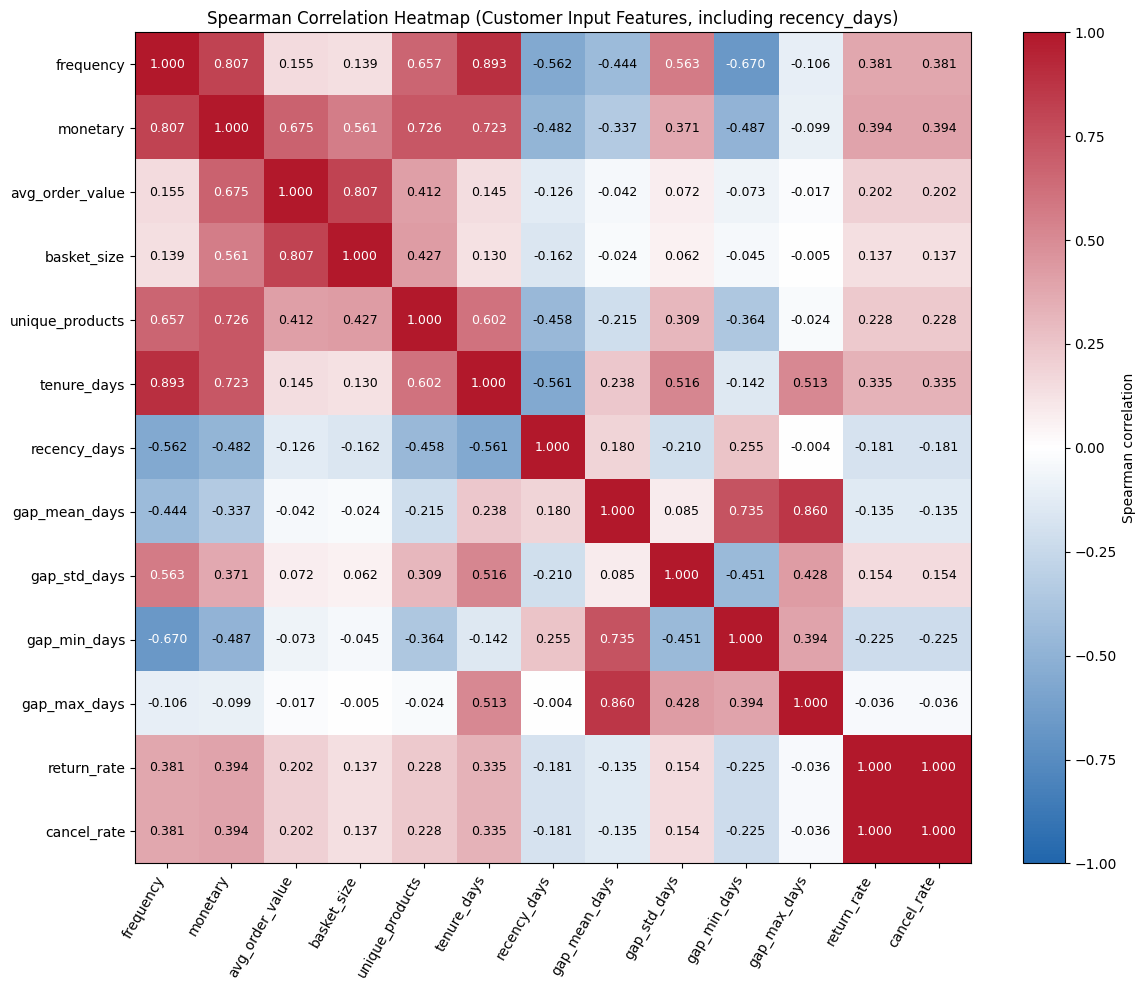

In [8]:
# Purpose:
# Inspect correlations among engineered features before modeling. This is
# useful for feature interpretation and spotting strongly related variables.

model_features = [
    "frequency","monetary","avg_order_value","basket_size","unique_products",
    "tenure_days","recency_days","gap_mean_days","gap_std_days","gap_min_days","gap_max_days",
    "return_rate","cancel_rate"
]

corr = cust[model_features].corr(method="spearman").round(3)

plot_annotated_heatmap(
    data=corr.values,
    xlabels=model_features,
    ylabels=model_features,
    title="Spearman Correlation Heatmap (Customer Input Features, including recency_days)",
    cbar_label="Spearman correlation",
    fmt=".3f",
    figsize=(12, 10),
    vmin=-1,
    vmax=1,
    center=0
)


## Module 5: Preprocessing (log1p + RobustScaler)

This module prepares customer features for clustering and classification.

### Steps applied
1. Fill missing values in gap-based and rate-based features
2. Apply `log1p` to skewed non-negative variables
3. Scale features using `RobustScaler`

### Why this matters
Retail features such as spending and order counts are usually highly skewed.  
Log transformation reduces extreme spread, while `RobustScaler` makes the models less sensitive to outliers than standard scaling.


In [ ]:
# Purpose:
# Prepare modeling matrices by handling missing values, reducing skew with
# log1p, and scaling numeric inputs with RobustScaler.

gap_cols = ["gap_mean_days", "gap_std_days", "gap_min_days", "gap_max_days"]
rate_cols = ["return_rate", "cancel_rate"]
log_cols = [
    "frequency", "monetary", "avg_order_value", "basket_size", "unique_products",
    "tenure_days", "recency_days", "gap_mean_days", "gap_std_days", "gap_min_days", "gap_max_days"
]

def prepare_model_matrix(feature_df, feature_cols, scaler=None, fit_scaler=False):
    """Return raw, transformed, and scaled matrices for a selected feature set."""
    X = feature_df[feature_cols].copy()

    existing_gap_cols = [c for c in gap_cols if c in X.columns]
    existing_rate_cols = [c for c in rate_cols if c in X.columns]

    if existing_gap_cols:
        X[existing_gap_cols] = X[existing_gap_cols].fillna(0)
    if existing_rate_cols:
        X[existing_rate_cols] = X[existing_rate_cols].fillna(0)

    X_log = X.copy()
    for c in [c for c in log_cols if c in X_log.columns]:
        X_log[c] = np.log1p(X_log[c].clip(lower=0))

    if fit_scaler:
        scaler = RobustScaler()
        X_scaled = scaler.fit_transform(X_log)
    else:
        if scaler is None:
            raise ValueError("Pass an existing scaler when fit_scaler=False.")
        X_scaled = scaler.transform(X_log)

    return X, X_log, X_scaled, scaler

X_raw_current, X_log, X_scaled, segmentation_scaler = prepare_model_matrix(
    cust, model_features, fit_scaler=True
)

print("X_scaled shape:", X_scaled.shape)
print("recency_days included in segmentation inputs:", "recency_days" in model_features)


## Module 6: Segmentation Model 1 — KMeans (Baseline) + Elbow Curve

This module trains a baseline KMeans clustering model directly on the processed customer feature matrix.

### What is evaluated
- Inertia across different values of `k` using the elbow curve
- Silhouette score
- Davies-Bouldin index
- Calinski-Harabasz score

These metrics help determine a reasonable number of clusters and provide a baseline to compare against the deep-learning-based segmentation approach.


,k,silhouette,davies_bouldin,calinski_harabasz,method
0,2,0.789531,0.574572,4816.498595,KMeans_raw
1,3,0.591241,0.674982,5008.801548,KMeans_raw
4,6,0.309970,0.950293,4283.946596,KMeans_raw
3,5,0.309471,0.938008,4494.512647,KMeans_raw
2,4,0.297852,0.992429,4481.642101,KMeans_raw
5,7,0.270912,1.064867,4053.432288,KMeans_raw
7,9,0.261893,0.991180,3841.466334,KMeans_raw
6,8,0.261893,1.038464,3892.890363,KMeans_raw
8,10,0.256854,1.035297,3734.330469,KMeans_raw


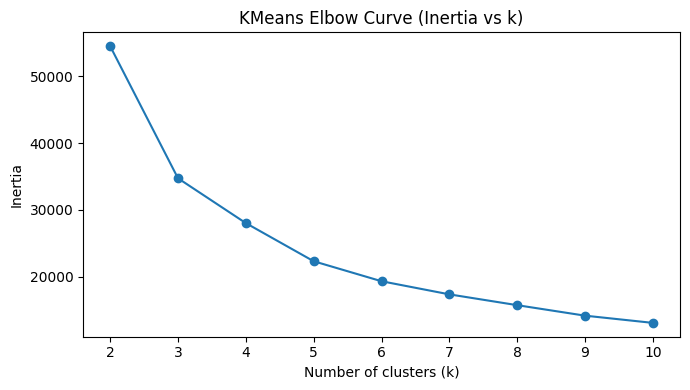

Best k for KMeans (raw features): 2


In [10]:
# Purpose:
# Train baseline KMeans models for several candidate values of k and compare
# cluster quality using common unsupervised evaluation metrics.

def cluster_metrics(Xs, labels):
    """Compute clustering quality metrics for a given label assignment."""
    k = len(np.unique(labels))
    if k <= 1:
        return {"k": k, "silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan}
    return {
        "k": k,
        "silhouette": float(silhouette_score(Xs, labels)),
        "davies_bouldin": float(davies_bouldin_score(Xs, labels)),
        "calinski_harabasz": float(calinski_harabasz_score(Xs, labels)),
    }

k_list = range(2, 11)

rows = []
inertias = []

# Evaluate multiple candidate cluster counts instead of assuming one k.
for k in k_list:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    r = cluster_metrics(X_scaled, labels)
    r.update({"method":"KMeans_raw","k":k})
    rows.append(r)

kmeans_raw_results = pd.DataFrame(rows).sort_values(["silhouette","calinski_harabasz"], ascending=[False, False])
display(kmeans_raw_results.head(10))

plt.figure(figsize=(7,4))
plt.plot(list(k_list), inertias, marker="o")
plt.title("KMeans Elbow Curve (Inertia vs k)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

best_k_raw = int(kmeans_raw_results.iloc[0]["k"])
print("Best k for KMeans (raw features):", best_k_raw)


## Module 7: Segmentation Model 2 — Autoencoder + KMeans (Deep Learning)

This module uses an autoencoder to learn a compressed representation of customer features before clustering.

### Why use an autoencoder
An autoencoder can capture non-linear structure in the input data and reduce the feature space into a compact latent representation.

### Workflow
- Train the autoencoder to reconstruct the scaled customer inputs
- Extract latent embeddings from the encoder
- Use those embeddings as inputs for KMeans
- Compare clustering quality against the baseline KMeans approach


In [ ]:
# Purpose:
# Learn a compressed latent representation of customer features with an
# autoencoder, then use that representation for clustering.

# If this fails, install:  !pip install torch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class AutoEncoder(nn.Module):
    """Simple fully connected autoencoder for non-linear feature compression."""
    def __init__(self, input_dim, latent_dim=6):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

split1 = int(len(X_scaled) * 0.7)
split2 = int(len(X_scaled) * 0.85)

X_train_ae = X_scaled[:split1]
X_val_ae   = X_scaled[split1:split2]
X_test_ae  = X_scaled[split2:]

train_loader = DataLoader(TensorDataset(torch.tensor(X_train_ae, dtype=torch.float32)),batch_size=512,shuffle=False)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val_ae, dtype=torch.float32)), batch_size=512, shuffle=False)
test_tensor  = torch.tensor(X_test_ae, dtype=torch.float32).to(device)

ae = AutoEncoder(input_dim=X_scaled.shape[1], latent_dim=6).to(device)
opt = torch.optim.Adam(ae.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

train_loss_history, val_loss_history = [], []
epochs = 25

for ep in range(1, epochs+1):
    ae.train()
    train_tot = 0.0
    for (xb,) in train_loader:
        xb = xb.to(device)
        opt.zero_grad()
        recon, _ = ae(xb)
        loss = loss_fn(recon, xb)
        loss.backward()
        opt.step()
        train_tot += loss.item() * xb.size(0)
    train_loss = train_tot / len(X_train_ae)
    train_loss_history.append(train_loss)

    ae.eval()
    val_tot = 0.0
    with torch.no_grad():
        for (xb,) in val_loader:
            xb = xb.to(device)
            recon, _ = ae(xb)
            val_tot += loss_fn(recon, xb).item() * xb.size(0)
    val_loss = val_tot / len(X_val_ae)
    val_loss_history.append(val_loss)

    if ep % 5 == 0 or ep == 1:
        print(f"Epoch {ep:02d}/{epochs}  train_loss={train_loss:.6f}  val_loss={val_loss:.6f}")

ae.eval()
with torch.no_grad():
    recon, _ = ae(test_tensor)
    test_loss = loss_fn(recon, test_tensor).item()
print("Final TEST loss (MSE):", round(test_loss, 6))

plt.figure(figsize=(7,4))
plt.plot(range(1, len(train_loss_history)+1), train_loss_history, label="Train")
plt.plot(range(1, len(val_loss_history)+1), val_loss_history, label="Validation")
plt.title("Autoencoder Loss (MSE) vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log scale)")
plt.legend()
plt.yscale("log")
plt.tight_layout()
plt.show()

ae.eval()
with torch.no_grad():
    _, Z = ae(torch.tensor(X_scaled, dtype=torch.float32).to(device))
Z = Z.cpu().numpy()
print("Embedding shape:", Z.shape)


### Module 7.1: KMeans on Embeddings + Compare with Baseline

This section applies KMeans to the learned autoencoder embeddings and compares the resulting cluster quality against the direct-feature baseline.

The goal is to check whether the learned latent space creates cleaner or more meaningful customer groups.


,k,silhouette,davies_bouldin,calinski_harabasz,method
0,2,0.833909,0.519177,6291.551758,KMeans_AE
1,3,0.701305,0.541215,7958.328613,KMeans_AE
2,4,0.615917,0.581596,8022.290039,KMeans_AE
5,7,0.489076,0.607841,10100.027344,KMeans_AE
4,6,0.487290,0.633872,9697.896484,KMeans_AE
6,8,0.482275,0.625228,10573.389648,KMeans_AE
3,5,0.472175,0.648445,8828.776367,KMeans_AE
7,9,0.449645,0.663634,10649.752930,KMeans_AE
8,10,0.410958,0.715404,10847.041992,KMeans_AE


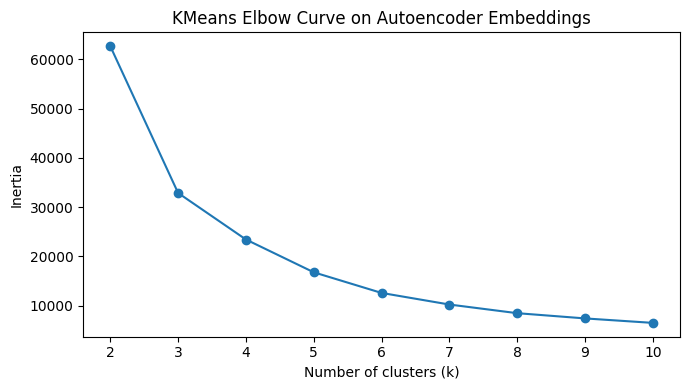

Best k for KMeans (AE embeddings): 2


,method,k,silhouette,davies_bouldin,calinski_harabasz
0,KMeans_raw,2,0.789531,0.574572,4816.498595
1,KMeans_AE,2,0.833909,0.519177,6291.551758


Final segmentation choice: AE+KMeans


In [12]:
# Purpose:
# Run KMeans on the learned embeddings and compare the clustering quality
# against the baseline KMeans approach.

rows = []
inertias_emb = []

for k in k_list:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(Z)
    inertias_emb.append(km.inertia_)
    r = cluster_metrics(Z, labels)
    r.update({"method":"KMeans_AE","k":k})
    rows.append(r)

kmeans_ae_results = pd.DataFrame(rows).sort_values(["silhouette","calinski_harabasz"], ascending=[False, False])
display(kmeans_ae_results.head(10))

plt.figure(figsize=(7,4))
plt.plot(list(k_list), inertias_emb, marker="o")
plt.title("KMeans Elbow Curve on Autoencoder Embeddings")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

best_k_ae = int(kmeans_ae_results.iloc[0]["k"])
print("Best k for KMeans (AE embeddings):", best_k_ae)

best_raw = kmeans_raw_results.iloc[0]
best_ae = kmeans_ae_results.iloc[0]
comp = pd.DataFrame([
    {"method":"KMeans_raw", **best_raw.to_dict()},
    {"method":"AE+KMeans", **best_ae.to_dict()},
])[["method","k","silhouette","davies_bouldin","calinski_harabasz"]]
display(comp)

use_ae = best_ae["silhouette"] >= best_raw["silhouette"]
print("Final segmentation choice:", "AE+KMeans" if use_ae else "KMeans_raw")


## Module 8: Final Segments + Segment Profile

This module selects the better segmentation approach, assigns each customer to a final segment, and builds a high-level profile for each segment.

### Output includes
- Segment ID for every customer
- Number of customers per segment
- Revenue contribution by segment
- Average frequency, recency, and monetary behavior per segment

This makes the clusters easier to interpret from a business perspective.


In [13]:
# Purpose:
# Choose the better segmentation approach, assign a final segment to each
# customer, and summarize segment-level business characteristics.

if use_ae:
    final_k = best_k_ae
    final_model = KMeans(n_clusters=final_k, n_init=10, random_state=42)
    cust["segment_id"] = final_model.fit_predict(Z)
else:
    final_k = best_k_raw
    final_model = KMeans(n_clusters=final_k, n_init=10, random_state=42)
    cust["segment_id"] = final_model.fit_predict(X_scaled)

segment_profile = cust.groupby("segment_id").agg(
    customers=("CustomerID","nunique"),
    monetary_total=("monetary","sum"),
    monetary_mean=("monetary","mean"),
    frequency_mean=("frequency","mean"),
    recency_mean=("recency_days","mean"),
).reset_index()

segment_profile["revenue_share"] = segment_profile["monetary_total"] / segment_profile["monetary_total"].sum()
display(segment_profile.sort_values("monetary_total", ascending=False))


,segment_id,customers,monetary_total,monetary_mean,frequency_mean,recency_mean,revenue_share
0,0,4173,8274742.464,1982.924147,4.299305,91.266475,0.928556
1,1,165,636665.440,3858.578424,3.581818,124.654545,0.071444


## Module 9: Retention Analysis (Cohorts)

This module performs monthly cohort analysis to visualize customer retention over time.

### What this heatmap is for
The cohort retention heatmap is a **descriptive business view** of repeat purchasing.  
Each row is a customer cohort based on first purchase month, and each column shows the share of that cohort that returned in later months.

### Why it matters
- Shows how quickly different acquisition cohorts decay or retain
- Helps compare repeat-purchase behavior across calendar periods
- Gives a direct business interpretation of retention over time

### How it differs from the Spearman heatmap
The **cohort retention heatmap** is about **customer behavior over time**.  
The **Spearman heatmap** is about **feature-to-feature association** within the engineered dataset.

So they answer two different questions:
- **Cohort heatmap:** “Do customers come back in later months?”
- **Spearman heatmap:** “Which numeric features move together?”


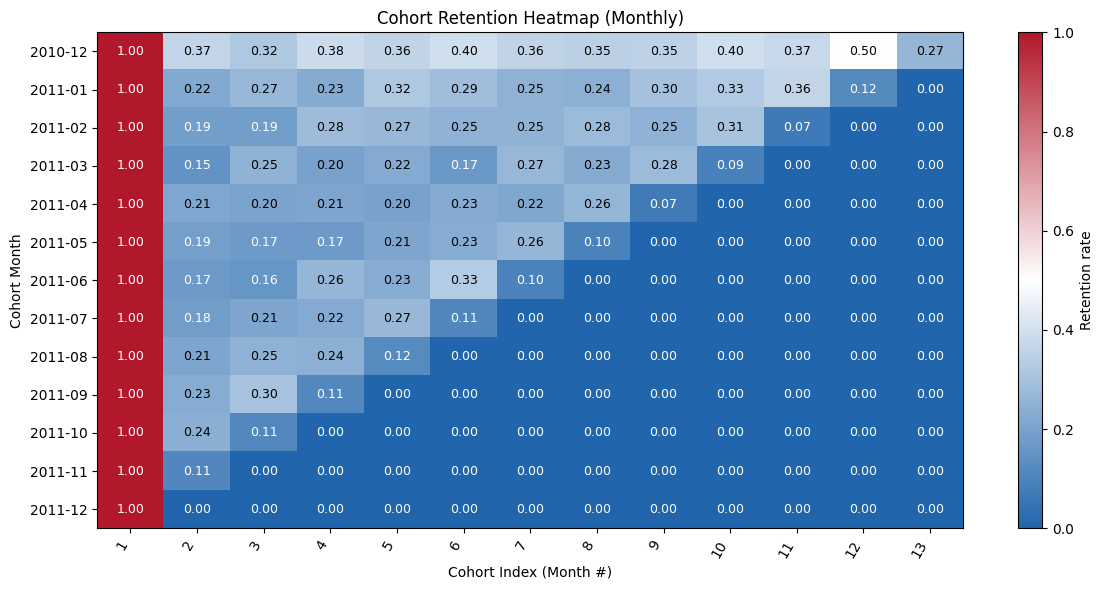

In [14]:
# Purpose:
# Build a monthly cohort-retention matrix to understand how repeat purchasing
# changes over time for customers acquired in different months.

df_c = df.copy()
df_c["InvoiceMonth"] = df_c["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

first_month = df_c.groupby("CustomerID")["InvoiceMonth"].min().rename("CohortMonth")
df_c = df_c.join(first_month, on="CustomerID")

def month_diff(a, b):
    """Return the month distance between two timestamps."""
    return (a.year - b.year) * 12 + (a.month - b.month)

df_c["CohortIndex"] = df_c.apply(lambda r: month_diff(r["InvoiceMonth"], r["CohortMonth"]) + 1, axis=1)

cohort_data = df_c.groupby(["CohortMonth","CohortIndex"])["CustomerID"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID").fillna(0)
retention = cohort_pivot.divide(cohort_pivot.iloc[:,0], axis=0)

plot_annotated_heatmap(
    data=retention.values,
    xlabels=retention.columns,
    ylabels=retention.index.strftime("%Y-%m"),
    title="Cohort Retention Heatmap (Monthly)",
    cbar_label="Retention rate",
    fmt=".2f",
    figsize=(12, 6),
    vmin=0,
    vmax=1,
    center=0.5,
    xlabel="Cohort Index (Month #)",
    ylabel="Cohort Month"
)


## Module 10: Churn Prediction — Leakage Check, Temporal Target, Tuning, and Final Selection

This module reformulates churn as a supervised classification problem in a way that avoids the main leakage issue from the earlier version.

### Key correction
The old setup defined churn from `recency_days` and also used `recency_days` as a model input.  
That can create near-perfect scores because the target is partly being fed directly into the model.

### Revised workflow
- Pick a **feature cutoff date**
- Build features using **only data available before the cutoff**
- Define churn as **no purchase in the next 90 days after the cutoff**
- Remove `recency_days` from the supervised feature set
- Compare base models, test `class_weight` as an on/off choice, then tune only the more useful hyperparameters
- Evaluate with ROC curves, confusion matrices, and convergence-style loss curves

This makes the classification task much more realistic and easier to defend in a report.


In [ ]:
# Purpose:
# Define a time-aware churn target, remove the leakage-prone feature from the
# supervised inputs, and train initial baseline models.

HOLDOUT_DAYS = 90
feature_cutoff = snapshot_date - pd.Timedelta(days=HOLDOUT_DAYS)

df_hist = df[df["InvoiceDate"] < feature_cutoff].copy()
df_future = df[(df["InvoiceDate"] >= feature_cutoff) & (df["InvoiceDate"] < snapshot_date)].copy()
df_flags_hist = df_flags[df_flags["InvoiceDate"] < feature_cutoff].copy()

eligible_customers = sorted(df_hist["CustomerID"].astype(str).unique())
cust_ml = build_customer_features(df_hist, df_flags_hist, feature_cutoff, customer_ids=eligible_customers)

future_buyers = set(df_future["CustomerID"].astype(str).unique())
cust_ml["future_purchase_next_90d"] = cust_ml["CustomerID"].isin(future_buyers).astype(int)
cust_ml["churned"] = (cust_ml["future_purchase_next_90d"] == 0).astype(int)

# Keep a simple current rule-based flag for export/reporting, but do not use it as the
# supervised target for model training.
cust["current_churn_flag"] = (cust["recency_days"] > HOLDOUT_DAYS).astype(int)

leakage_audit = pd.DataFrame([
    {"check": "feature_cutoff", "value": str(feature_cutoff)},
    {"check": "target_definition", "value": f"No purchase in next {HOLDOUT_DAYS} days"},
    {"check": "features_use_future_data", "value": False},
    {"check": "recency_days_removed_from_churn_inputs", "value": True},
    {"check": "customers_in_temporal_modeling_table", "value": int(len(cust_ml))}
])
display(leakage_audit)

display(cust_ml["churned"].value_counts(normalize=True).rename("class_ratio"))

recency_target_corr = pd.DataFrame([
    {
        "metric": "Spearman correlation: recency_days vs churn target",
        "value": round(
            pd.Series(cust_ml["recency_days"]).corr(pd.Series(cust_ml["churned"]), method="spearman"),
            4
        )
    }
])
display(recency_target_corr)

churn_model_features = [c for c in model_features if c != "recency_days"]

print("Temporal churn target: no purchase in next", HOLDOUT_DAYS, "days")
print("Feature cutoff:", feature_cutoff)
print("recency_days removed from churn model inputs:", "recency_days" not in churn_model_features)

_, X_ml_log, _, _ = prepare_model_matrix(cust_ml, churn_model_features, fit_scaler=True)
y = cust_ml["churned"].astype(int).values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_ml_log, y, test_size=0.20, random_state=42, stratify=y
)

churn_scaler = RobustScaler()
X_train = churn_scaler.fit_transform(X_train_raw)
X_test = churn_scaler.transform(X_test_raw)
X_all_train = churn_scaler.transform(X_ml_log)

_, X_score_log_current, X_score_scaled_current, _ = prepare_model_matrix(
    cust, churn_model_features, scaler=churn_scaler, fit_scaler=False
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

def lift_at_k(y_true, y_prob, k=0.10):
    n = len(y_true)
    top_n = max(1, int(n * k))
    idx = np.argsort(-y_prob)[:top_n]
    captured = y_true[idx].sum()
    base = y_true.sum() * (top_n / n)
    return float(captured / (base + 1e-9))

def evaluate_model(name, model, Xtr, ytr, Xte, yte, threshold=0.50):
    fitted = clone(model)
    fitted.fit(Xtr, ytr)
    prob = fitted.predict_proba(Xte)[:, 1]
    pred = (prob >= threshold).astype(int)
    return {
        "model": name,
        "accuracy": float(accuracy_score(yte, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(yte, pred)),
        "precision": float(precision_score(yte, pred, zero_division=0)),
        "recall": float(recall_score(yte, pred, zero_division=0)),
        "f1": float(f1_score(yte, pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(yte, prob)),
        "pr_auc": float(average_precision_score(yte, prob)),
        "lift@10%": float(lift_at_k(yte, prob, 0.10)),
        "log_loss": float(log_loss(yte, prob)),
        "prob": prob,
        "pred": pred,
        "cm": confusion_matrix(yte, pred)
    }

base_models = {
    "LogReg": LogisticRegression(max_iter=3000, random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    ),
    "HistGB": HistGradientBoostingClassifier(random_state=42)
}

base_eval_cache = {}
base_rows = []
for name, model in base_models.items():
    result = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    base_eval_cache[name] = result
    base_rows.append({k: v for k, v in result.items() if k not in ["prob", "pred", "cm"]})

base_score_df = pd.DataFrame(base_rows).sort_values(
    ["pr_auc", "recall", "roc_auc", "f1"], ascending=False
).reset_index(drop=True)

print("Base model results (before hyperparameter tuning):")
display(base_score_df)


In [ ]:
# Purpose:
# Compare class-weight ON vs OFF as a separate analysis, then tune only the
# more useful hyperparameters.

### Module 10.1: Class-weight analysis + Hyperparameter Tuning

weight_variant_rows = []

for weighted in [False, True]:
    lr_variant = LogisticRegression(
        max_iter=3000,
        random_state=42,
        class_weight="balanced" if weighted else None
    )
    rf_variant = RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample" if weighted else None
    )

    for model_name, model in [("LogReg", lr_variant), ("RandomForest", rf_variant)]:
        result = evaluate_model(
            f"{model_name} | weighted={weighted}",
            model,
            X_train,
            y_train,
            X_test,
            y_test
        )
        weight_variant_rows.append({
            "model": model_name,
            "weighted": weighted,
            "pr_auc": result["pr_auc"],
            "roc_auc": result["roc_auc"],
            "recall": result["recall"],
            "f1": result["f1"],
            "log_loss": result["log_loss"]
        })

weight_variant_df = pd.DataFrame(weight_variant_rows).sort_values(
    ["model", "pr_auc", "recall", "roc_auc"],
    ascending=[True, False, False, False]
).reset_index(drop=True)

print("Class-weight ON/OFF analysis:")
display(weight_variant_df)

best_lr_weighted = bool(
    weight_variant_df[weight_variant_df["model"] == "LogReg"].iloc[0]["weighted"]
)
best_rf_weighted = bool(
    weight_variant_df[weight_variant_df["model"] == "RandomForest"].iloc[0]["weighted"]
)

print("Chosen LogisticRegression class_weight:", "balanced" if best_lr_weighted else None)
print("Chosen RandomForest class_weight:", "balanced_subsample" if best_rf_weighted else None)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search_spaces = {
    "LogReg": {
        "estimator": LogisticRegression(
            max_iter=5000,
            random_state=42,
            class_weight="balanced" if best_lr_weighted else None
        ),
        "params": {
            "C": loguniform(1e-4, 1e2),
            "solver": ["lbfgs", "liblinear"]
        },
        "n_iter": 12
    },
    "RandomForest": {
        "estimator": RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample" if best_rf_weighted else None
        ),
        "params": {
            "n_estimators": randint(200, 900),
            "max_depth": [None, 5, 10, 15, 20, 30],
            "min_samples_split": randint(2, 12),
            "min_samples_leaf": randint(1, 6),
            "max_features": ["sqrt", "log2", None]
        },
        "n_iter": 16
    },
    "HistGB": {
        "estimator": HistGradientBoostingClassifier(random_state=42),
        "params": {
            "learning_rate": loguniform(1e-4, 5e-1),
            "max_depth": [None, 3, 5, 7, 10],
            "max_leaf_nodes": randint(15, 63),
            "min_samples_leaf": randint(10, 60),
            "l2_regularization": loguniform(1e-4, 1.0),
            "max_iter": randint(120, 420)
        },
        "n_iter": 16
    }
}

tuned_models = {}
tuning_summary = []

for name, spec in search_spaces.items():
    search = RandomizedSearchCV(
        estimator=spec["estimator"],
        param_distributions=spec["params"],
        n_iter=spec["n_iter"],
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        refit=True
    )
    search.fit(X_train, y_train)

    tuned_models[name] = search.best_estimator_
    tuning_summary.append({
        "model": name,
        "best_cv_pr_auc": float(search.best_score_),
        "best_params": str(search.best_params_)
    })

tuning_summary_df = pd.DataFrame(tuning_summary).sort_values(
    "best_cv_pr_auc", ascending=False
).reset_index(drop=True)

print("Best cross-validated PR-AUC and tuned parameters:")
display(tuning_summary_df)

tuned_eval_cache = {}
tuned_rows = []
for name, model in tuned_models.items():
    result = evaluate_model(f"{name} (tuned)", model, X_train, y_train, X_test, y_test)
    tuned_eval_cache[name] = result
    tuned_rows.append({k: v for k, v in result.items() if k not in ["prob", "pred", "cm"]})

tuned_score_df = pd.DataFrame(tuned_rows).sort_values(
    ["pr_auc", "recall", "roc_auc", "f1"], ascending=False
).reset_index(drop=True)

print("Tuned model results on the test set:")
display(tuned_score_df)

model_comparison_df = (
    pd.concat([
        base_score_df.assign(stage="Base"),
        tuned_score_df.assign(stage="Tuned")
    ], ignore_index=True)
    .sort_values(["stage", "pr_auc", "recall", "roc_auc", "f1"], ascending=[True, False, False, False, False])
    .reset_index(drop=True)
)

print("Full comparison of base vs tuned models:")
display(model_comparison_df)

best_model_name = tuned_score_df.iloc[0]["model"]
best_model_key = best_model_name.replace(" (tuned)", "")
print("Final best model selected after testing and tuning all models:", best_model_name)
print("Selection rule: highest PR-AUC, then Recall, then ROC-AUC, then F1")


In [ ]:
# Purpose:
# Visualize tuned-model classification performance on the held-out temporal
# test split using ROC curves and confusion matrices.

### Module 10.2: ROC Curves + Confusion Matrices (Tuned Models)

n_models = len(tuned_models)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4.5 * n_models))
if n_models == 1:
    axes = np.array([axes])

for row_idx, (name, model) in enumerate(tuned_models.items()):
    result = tuned_eval_cache[name]
    prob = result["prob"]
    pred = result["pred"]
    cm = result["cm"]

    ax_roc = axes[row_idx, 0]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score = roc_auc_score(y_test, prob)
    pr_score = average_precision_score(y_test, prob)

    ax_roc.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    ax_roc.plot([0, 1], [0, 1], linestyle="--", label="Random")
    ax_roc.set_title(f"{name} ROC Curve")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.legend(title=f"PR-AUC = {pr_score:.3f}")

    ax_cm = axes[row_idx, 1]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax_cm, colorbar=False)
    ax_cm.set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()


In [ ]:
# Purpose:
# Show optimization / convergence curves against iterations or epochs instead
# of training size.

### Module 10.3: Convergence Curves (Loss vs Iteration / Epoch)

print("Note: Random Forest is not trained by epochs like a neural network.")
print("For Random Forest, an OOB error vs number-of-trees curve is more meaningful than an epoch-loss curve.")

def plot_logreg_convergence_curve(Xtr, ytr, Xva, yva, C=1.0, epochs=40):
    model = LogisticRegression(
        solver="saga",
        penalty="l2",
        C=C,
        max_iter=1,
        warm_start=True,
        random_state=42
    )
    train_loss = []
    val_loss = []

    for _ in range(epochs):
        model.fit(Xtr, ytr)
        train_prob = model.predict_proba(Xtr)[:, 1]
        val_prob = model.predict_proba(Xva)[:, 1]
        train_loss.append(log_loss(ytr, train_prob, labels=[0, 1]))
        val_loss.append(log_loss(yva, val_prob, labels=[0, 1]))

    plt.figure(figsize=(7, 4))
    plt.plot(range(1, epochs + 1), train_loss, label="Train")
    plt.plot(range(1, epochs + 1), val_loss, label="Validation")
    plt.title("Logistic Regression Convergence (log-loss vs epoch)")
    plt.xlabel("Epoch")
    plt.ylabel("Log loss (log scale)")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_histgb_convergence_curve(base_model, Xtr, ytr):
    model = clone(base_model)
    model.set_params(early_stopping=True, validation_fraction=0.2, scoring="loss")
    model.fit(Xtr, ytr)

    train_loss = -np.asarray(model.train_score_)
    val_loss = -np.asarray(model.validation_score_)
    iters = np.arange(1, len(train_loss) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(iters, train_loss, label="Train")
    plt.plot(iters, val_loss, label="Validation")
    plt.title("HistGradientBoosting Convergence (loss vs boosting iteration)")
    plt.xlabel("Boosting iteration")
    plt.ylabel("Loss (log scale)")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_random_forest_oob_curve(weighted, Xtr, ytr, max_trees=400, step=25):
    rf = RandomForestClassifier(
        n_estimators=step,
        warm_start=True,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample" if weighted else None
    )

    tree_counts = []
    oob_errors = []

    for n_trees in range(step, max_trees + 1, step):
        rf.set_params(n_estimators=n_trees)
        rf.fit(Xtr, ytr)
        tree_counts.append(n_trees)
        oob_errors.append(1 - rf.oob_score_)

    plt.figure(figsize=(7, 4))
    plt.plot(tree_counts, oob_errors, marker="o")
    plt.title("Random Forest OOB Error vs Number of Trees")
    plt.xlabel("Number of trees")
    plt.ylabel("OOB error")
    plt.tight_layout()
    plt.show()

best_logreg_C = tuned_models["LogReg"].get_params().get("C", 1.0)
plot_logreg_convergence_curve(X_train, y_train, X_test, y_test, C=best_logreg_C, epochs=40)
plot_histgb_convergence_curve(tuned_models["HistGB"], X_train, y_train)
plot_random_forest_oob_curve(best_rf_weighted, X_train, y_train)


In [ ]:
# Purpose:
# Test an additional churn-modeling variation where the churn inputs are first
# compressed with a Keras autoencoder and then modeled with classical ML.

### Module 10.4: Autoencoder Feature Compression + Classical Models

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(8, activation="relu")(input_layer)
encoded = Dense(5, activation="relu")(encoded)

decoded = Dense(8, activation="relu")(encoded)
decoded = Dense(input_dim, activation="sigmoid")(decoded)

autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

autoencoder.compile(optimizer="adam", loss="mse")


In [ ]:
# Train the Keras autoencoder and monitor reconstruction performance on a
# validation split.

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Keras Autoencoder Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log scale)")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Transform train and test features into the learned latent space.

X_train_enc = encoder.predict(X_train)
X_test_enc = encoder.predict(X_test)

In [ ]:
# Fit a Random Forest on the compressed features as an additional experiment.

from sklearn.ensemble import RandomForestClassifier

rf_auto = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf_auto.fit(X_train_enc, y_train)

In [ ]:
# Evaluate the compressed-feature Random Forest on the test set.

from sklearn.metrics import accuracy_score

y_pred_auto = rf_auto.predict(X_test_enc)

print("Autoencoder Model Accuracy:", accuracy_score(y_test, y_pred_auto))

In [ ]:
# Compare multiple classical models on the compressed features to see whether
# the learned latent representation helps downstream churn prediction.

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_enc, y_train)
y_pred_log = log_model.predict(X_test_enc)
log_acc = accuracy_score(y_test, y_pred_log)

# Histogram Gradient Boosting
hist_model = HistGradientBoostingClassifier()
hist_model.fit(X_train_enc, y_train)
y_pred_hist = hist_model.predict(X_test_enc)
hist_acc = accuracy_score(y_test, y_pred_hist)

# Define rf_accuracy using y_pred_auto from previous cell
rf_accuracy = accuracy_score(y_test, y_pred_auto)

# Combine all results
results = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'HistGB'],
    'Accuracy': [rf_accuracy, log_acc, hist_acc]
})

print(results)

## Module 10.5: Model Interpretation

This section explains the corrected churn models after training.

### Outputs included
- **Random Forest feature importance** to show which variables contribute most to tree-based predictions
- **Logistic Regression coefficients** to show the direction and strength of linear effects

### Important interpretation note
In the revised supervised setup, `recency_days` is **not** included as a churn-model input.  
That keeps the interpretation cleaner and avoids the earlier leakage problem where one feature could dominate simply because the target was derived from it.


In [ ]:
# Purpose:
# Refit the best tested churn model on the full temporal training table, then
# score the current customer base using the same leakage-safe feature set.

## Module 11: Current Customer Risk Scoring (Best Tested Model)

best_model_template = tuned_models[best_model_key]
best_model = clone(best_model_template)
best_model.fit(X_all_train, y)

risk_prob = best_model.predict_proba(X_score_scaled_current)[:, 1]
cust["risk_prob"] = risk_prob
cust["risk_score"] = (cust["risk_prob"] * 100).round(1)

value = np.log1p(cust["monetary"].values)
value_n = (value - value.min()) / (value.max() - value.min() + 1e-9)
cust["value_score"] = (value_n * 100).round(1)

cust["priority_score"] = (value_n * cust["risk_prob"] * 100).round(1)

seg_prof = cust.groupby("segment_id").agg(
    monetary_mean=("monetary", "mean"),
    frequency_mean=("frequency", "mean"),
    recency_mean=("recency_days", "mean"),
).reset_index()

med_value = seg_prof["monetary_mean"].median()
med_recency = seg_prof["recency_mean"].median()
med_freq = seg_prof["frequency_mean"].median()

def seg_name(r):
    hv = r["monetary_mean"] >= med_value
    hr = r["recency_mean"] >= med_recency
    hf = r["frequency_mean"] >= med_freq
    if hv and hf and not hr:
        return "VIP Loyalists"
    if hv and hr:
        return "High Value At-Risk"
    if (not hv) and hf and not hr:
        return "Frequent Budget Buyers"
    if (not hv) and hr:
        return "One-time / Churned"
    return "Growth Potential"

seg_prof["segment_name"] = seg_prof.apply(seg_name, axis=1)
seg_map = seg_prof.set_index("segment_id")["segment_name"].to_dict()
cust["segment_name"] = cust["segment_id"].map(seg_map)

seg_means = cust.groupby("segment_id")[model_features].mean()

def analyze_customer(customer_id):
    row = cust[cust["CustomerID"] == str(customer_id)]
    if row.empty:
        return None
    row = row.iloc[0]
    sid = int(row["segment_id"])
    diffs = (row[model_features] - seg_means.loc[sid]).abs().sort_values(ascending=False)
    top_drivers = diffs.head(5).index.tolist()
    return {
        "CustomerID": row["CustomerID"],
        "segment_name": row["segment_name"],
        "risk_score_0_100": float(row["risk_score"]),
        "value_score_0_100": float(row["value_score"]),
        "priority_score_0_100": float(row["priority_score"]),
        "top_drivers": top_drivers,
        "best_tested_model": best_model_name,
    }

analyze_customer(cust["CustomerID"].iloc[0])


In [ ]:
# Purpose:
# Build exportable interpretation tables using the leakage-safe supervised
# feature set.

## Module 12: Export-ready interpretation tables

rf_tuned = tuned_models["RandomForest"]
rf_tuned.fit(X_train, y_train)

rf_imp = pd.DataFrame({
    "feature": churn_model_features,
    "importance": rf_tuned.feature_importances_
}).sort_values("importance", ascending=False)

logreg_tuned = tuned_models["LogReg"]
logreg_tuned.fit(X_train, y_train)

logreg_coef = pd.DataFrame({
    "feature": churn_model_features,
    "coefficient": logreg_tuned.coef_.ravel()
}).sort_values("coefficient", key=np.abs, ascending=False)

display(rf_imp.head(10))
display(logreg_coef.head(10))


In [ ]:
# Purpose:
# Provide interpretable summaries of the tuned models using feature importance
# for Random Forest and coefficients for Logistic Regression.

# RandomForest feature importance
rf_tuned = tuned_models["RandomForest"]
rf_tuned.fit(X_train, y_train)

rf_imp = pd.DataFrame({
    "feature": churn_model_features,
    "importance": rf_tuned.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(rf_imp["feature"][::-1], rf_imp["importance"][::-1])
plt.title("RandomForest (tuned) Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(rf_imp)

# LogisticRegression coefficients
logreg_tuned = tuned_models["LogReg"]
logreg_tuned.fit(X_train, y_train)

logreg_coef = pd.DataFrame({
    "feature": churn_model_features,
    "coefficient": logreg_tuned.coef_.ravel()
}).sort_values("coefficient", key=np.abs, ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(logreg_coef["feature"][::-1], logreg_coef["coefficient"][::-1])
plt.title("LogisticRegression (tuned) Coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

display(logreg_coef)


In [ ]:
# Purpose:
# Export the final scored customer table and model-comparison outputs after all
# interpretability artifacts have been created.

## Module 13: Export CSVs

export_cols = [
    "CustomerID", "segment_id", "segment_name",
    "monetary", "frequency", "recency_days", "tenure_days",
    "current_churn_flag", "risk_prob", "risk_score", "value_score", "priority_score"
]

cust[export_cols].sort_values("priority_score", ascending=False).to_csv(
    "customer_segments_and_risk.csv", index=False
)
cust[export_cols].sort_values("priority_score", ascending=False).head(200).to_csv(
    "priority_high_value_high_risk.csv", index=False
)

model_comparison_df.to_csv("churn_model_comparison.csv", index=False)
tuning_summary_df.to_csv("churn_model_tuning_summary.csv", index=False)
weight_variant_df.to_csv("class_weight_on_off_analysis.csv", index=False)
rf_imp.to_csv("randomforest_feature_importance.csv", index=False)
logreg_coef.to_csv("logreg_coefficients.csv", index=False)

print("Saved CSVs.")
print("Best tested model:", best_model_name)


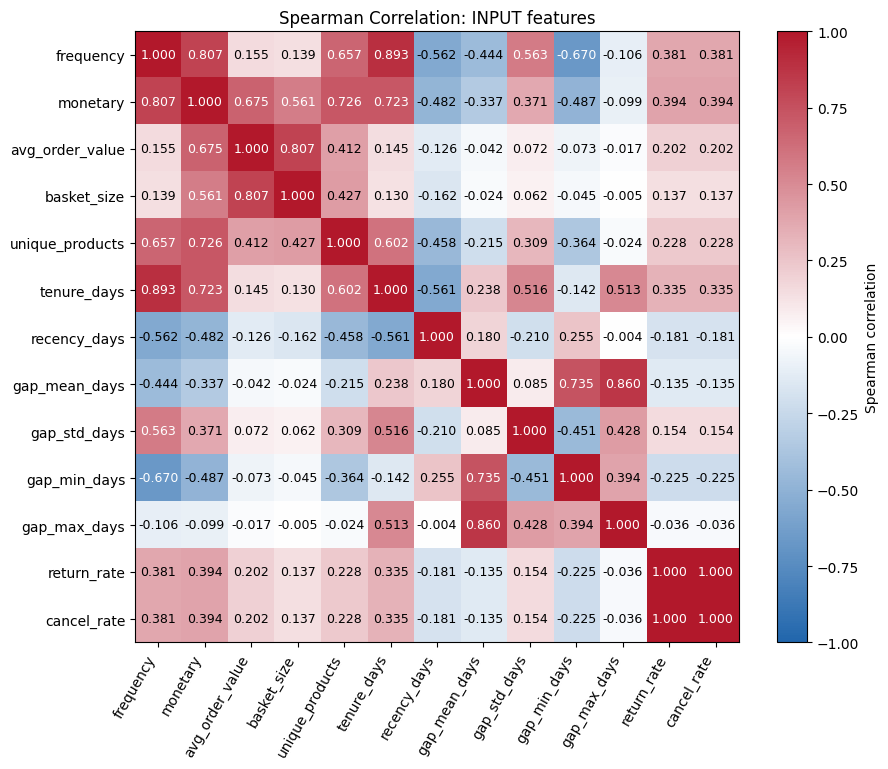

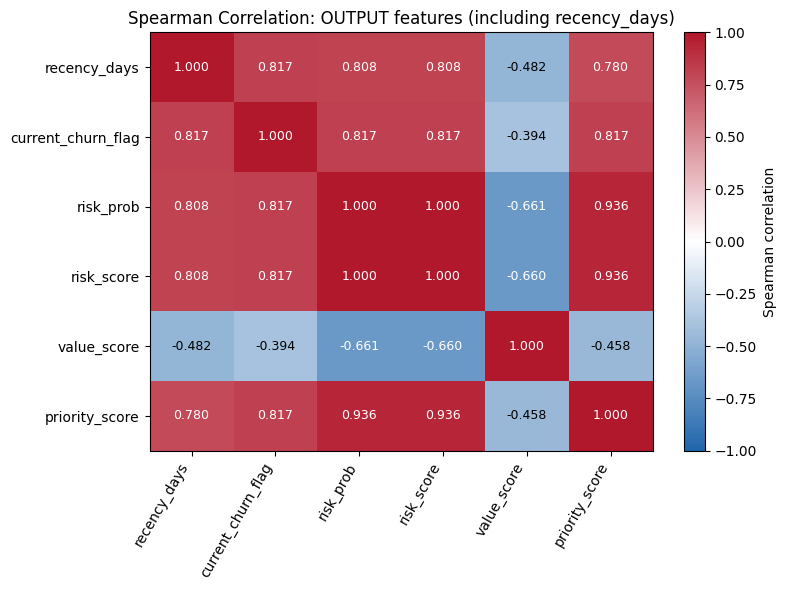

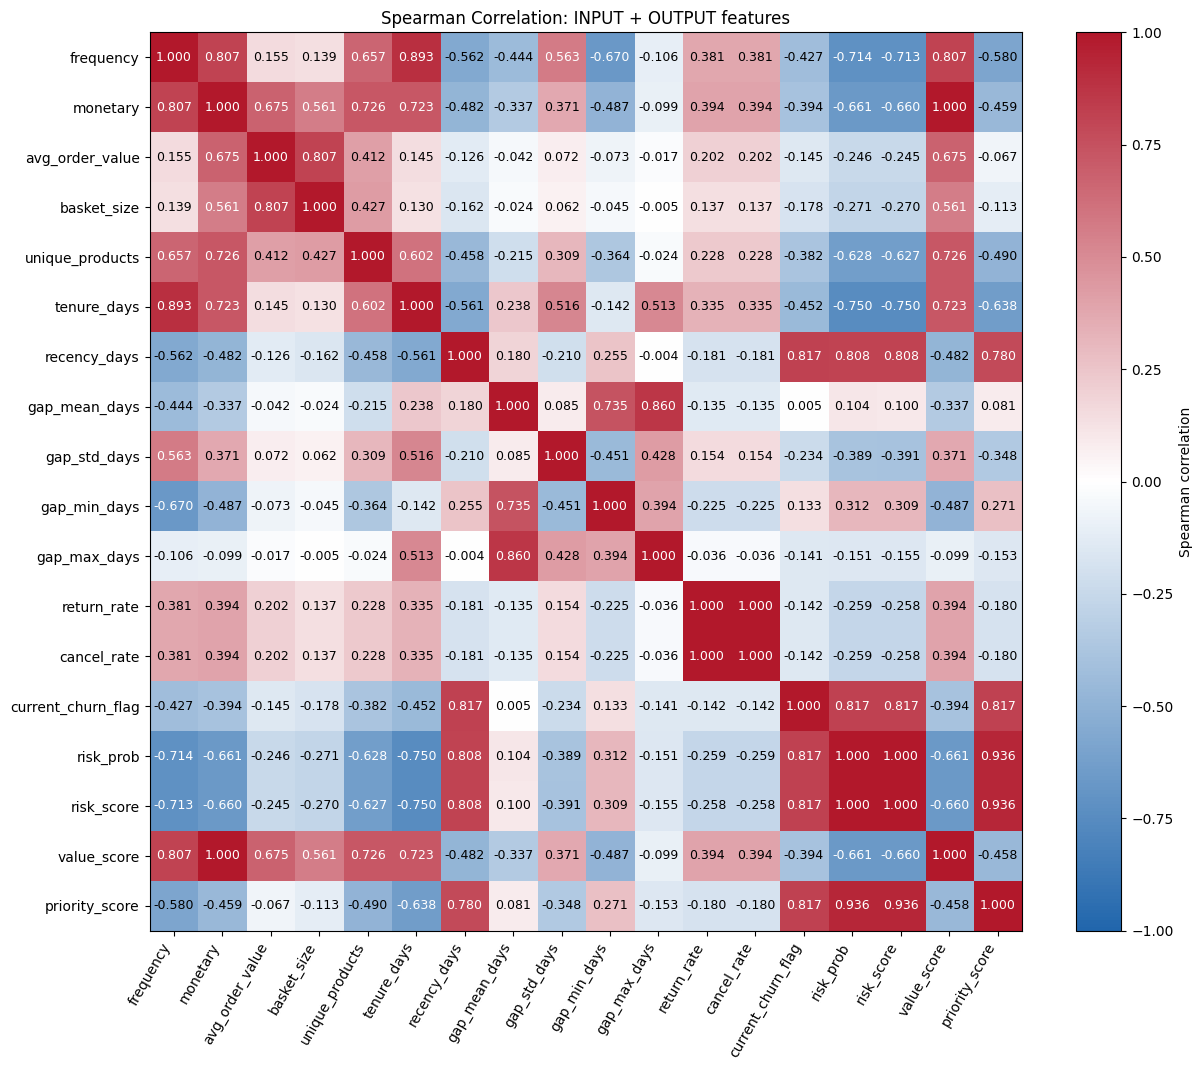

In [32]:
# Purpose:
# Define a reusable helper that can compute and visualize an annotated
# correlation matrix for any set of valid dataframe columns.

import numpy as np
import matplotlib.pyplot as plt

def corr_table_and_heatmap(df, cols, title, method="spearman"):
    """Create a correlation table and matching annotated heatmap for selected columns."""
    cols = [c for c in cols if c in df.columns]
    if len(cols) < 2:
        print("Not enough columns to compute correlation for:", title)
        return None

    corr = df[cols].corr(method=method).round(3)

    fig_w = max(8, 0.7 * len(cols))
    fig_h = max(6, 0.6 * len(cols))

    plot_annotated_heatmap(
        data=corr.values,
        xlabels=cols,
        ylabels=cols,
        title=title,
        cbar_label=f"{method.title()} correlation",
        fmt=".3f",
        figsize=(fig_w, fig_h),
        vmin=-1,
        vmax=1,
        center=0
    )

    return corr

# Final inputs (engineered features)
input_cols = model_features

# Final outputs (target / model outputs / decision scores)
output_cols = ["recency_days", "current_churn_flag", "risk_prob", "risk_score", "value_score", "priority_score"]

# A) Inputs-only
corr_inputs = corr_table_and_heatmap(cust, input_cols, "Spearman Correlation: INPUT features")

# B) Outputs-only
corr_outputs = corr_table_and_heatmap(cust, output_cols, "Spearman Correlation: OUTPUT features (including recency_days)")

# C) Inputs + Outputs together (deduplicated)
io_cols = list(dict.fromkeys(input_cols + output_cols))
corr_io = corr_table_and_heatmap(cust, io_cols, "Spearman Correlation: INPUT + OUTPUT features")
